In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Science

In [2]:
df_restaurants = pd.read_csv("resturants.csv")

In [3]:
df_restaurants.head()

,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe


In [4]:
df_items = pd.read_csv("items.csv")

In [5]:
df_items.head()

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


In [6]:
df_sales = pd.read_csv("sales.csv", date_format = '%y-%m-%d')
df_sales['date'] = pd.to_datetime(df_sales['date'])
df_sales.head()

,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


In [7]:
from scipy.stats import zscore
import numpy as np
def get_outliers(df, col):
    z_col = zscore(df[col])
    threshold = 2
    outlier = np.where(z_col - threshold > 0, True, np.where(z_col + threshold < 0, True, False))
    return df[outlier == True].index.tolist()

def remove_outliers(df, cols):
 outliers = []
 for col in cols:
     outliers.extend(get_outliers(df, col))
 return df.drop(index=outliers, axis=0)

In [8]:
df_items2 = remove_outliers(df_items, ["kcal", "cost"])
df_sales["date_int"] = df_sales["date"].dt.strftime('%Y%m%d').astype(int)
df_sales2 = remove_outliers(df_sales, ["date_int", "price", "item_count"])

In [9]:
def factorize(df, cols):
 for col in cols:
     codes, _ = pd.factorize(df[col])
     df[f"{col}_F"] = codes

In [10]:
factorize(df_items2, ["name"])
factorize(df_restaurants, ["name"])

In [11]:
df_all = pd.merge(df_sales2, df_items2, left_on="item_id", right_on="id", left_index=False, right_index=False)
df_all.drop(columns=["id"], inplace=True)
df_all.rename(columns={"name": "item_name", "name_F": "item_name_F"}, inplace=True)
df_all = pd.merge(df_all, df_restaurants, left_on="store_id", right_on="id", left_index=False, right_index=False)
df_all.drop(columns=["id"], inplace=True)
df_all.rename(columns={"name": "store_name", "name_F": "store_name_F"}, inplace=True)
df_all = df_all[["date", "date_int", "item_id", "price", "item_count", "item_name", "item_name_F", "kcal", "store_id", "store_name", "store_name_F"]]
df_all = df_all[df_all["item_count"] > 0.0]
df_all

,date,date_int,item_id,price,item_count,item_name,item_name_F,kcal,store_id,store_name,store_name_F
0,2019-01-01,20190101,3,29.22,2.0,Sweet Fruity Cake,2,931,1,Bob's Diner,0
1,2019-01-01,20190101,4,26.42,22.0,Amazing Steak Dinner with Rolls,3,763,1,Bob's Diner,0
2,2019-01-01,20190101,12,4.87,7.0,Fantastic Sweet Cola,11,478,1,Bob's Diner,0
3,2019-01-01,20190101,13,4.18,12.0,Sweet Frozen Soft Drink,12,490,1,Bob's Diner,0
4,2019-01-01,20190101,21,23.23,13.0,Amazing Fish with Vegetables Meal,20,269,1,Bob's Diner,0
...,...,...,...,...,...,...,...,...,...,...,...
102354,2021-12-31,20211231,59,23.37,54.0,Blue Ribbon Beef Entree,56,392,1,Bob's Diner,0
102355,2021-12-31,20211231,67,7.00,6.0,Sweet Lamb Cake,64,558,1,Bob's Diner,0
102356,2021-12-31,20211231,68,8.70,1.0,Blue Ribbon Fruity Milky Cake,65,652,1,Bob's Diner,0
102357,2021-12-31,20211231,73,5.16,10.0,Milky Cake,39,596,1,Bob's Diner,0


Distribution of Features


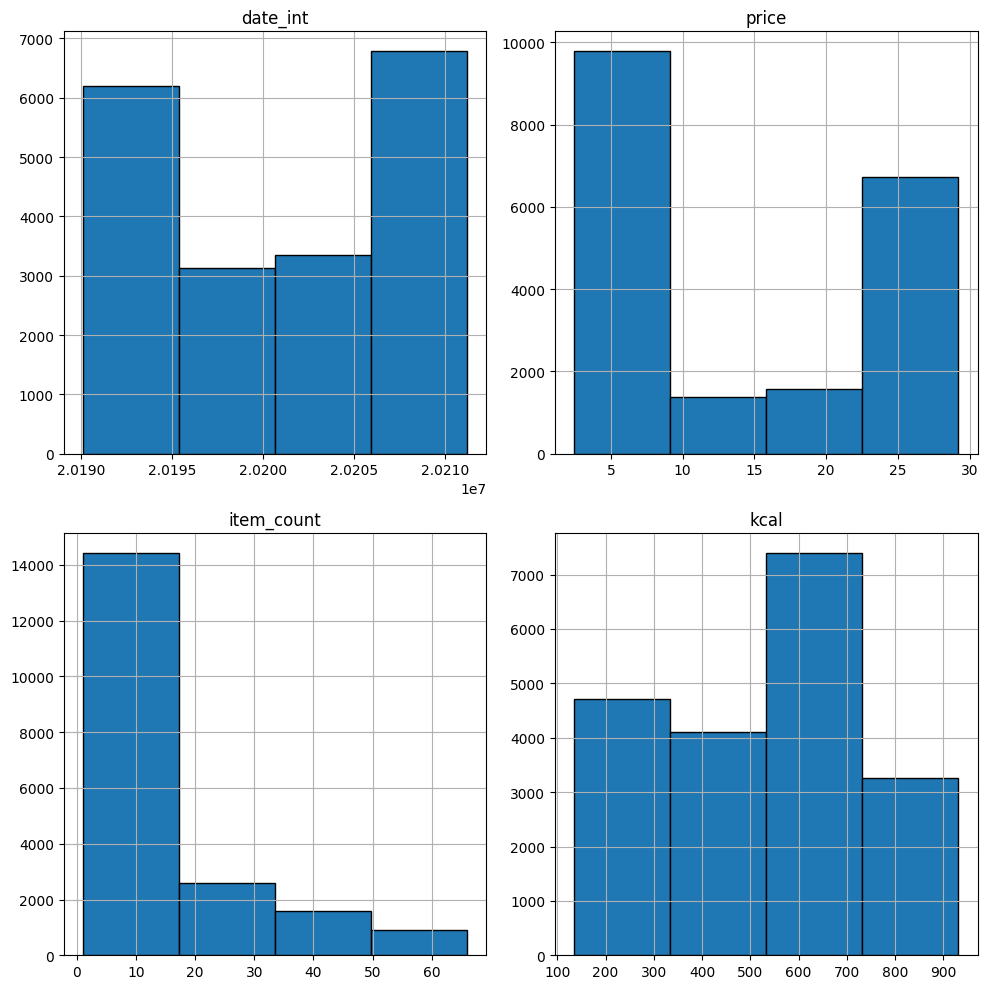

In [12]:
df_features = df_all[["date_int", "price", "item_count", "kcal"]]
df_features.hist(bins=4, figsize=(10, 10), edgecolor='black')
plt.tight_layout()
print("Distribution of Features")
plt.show()

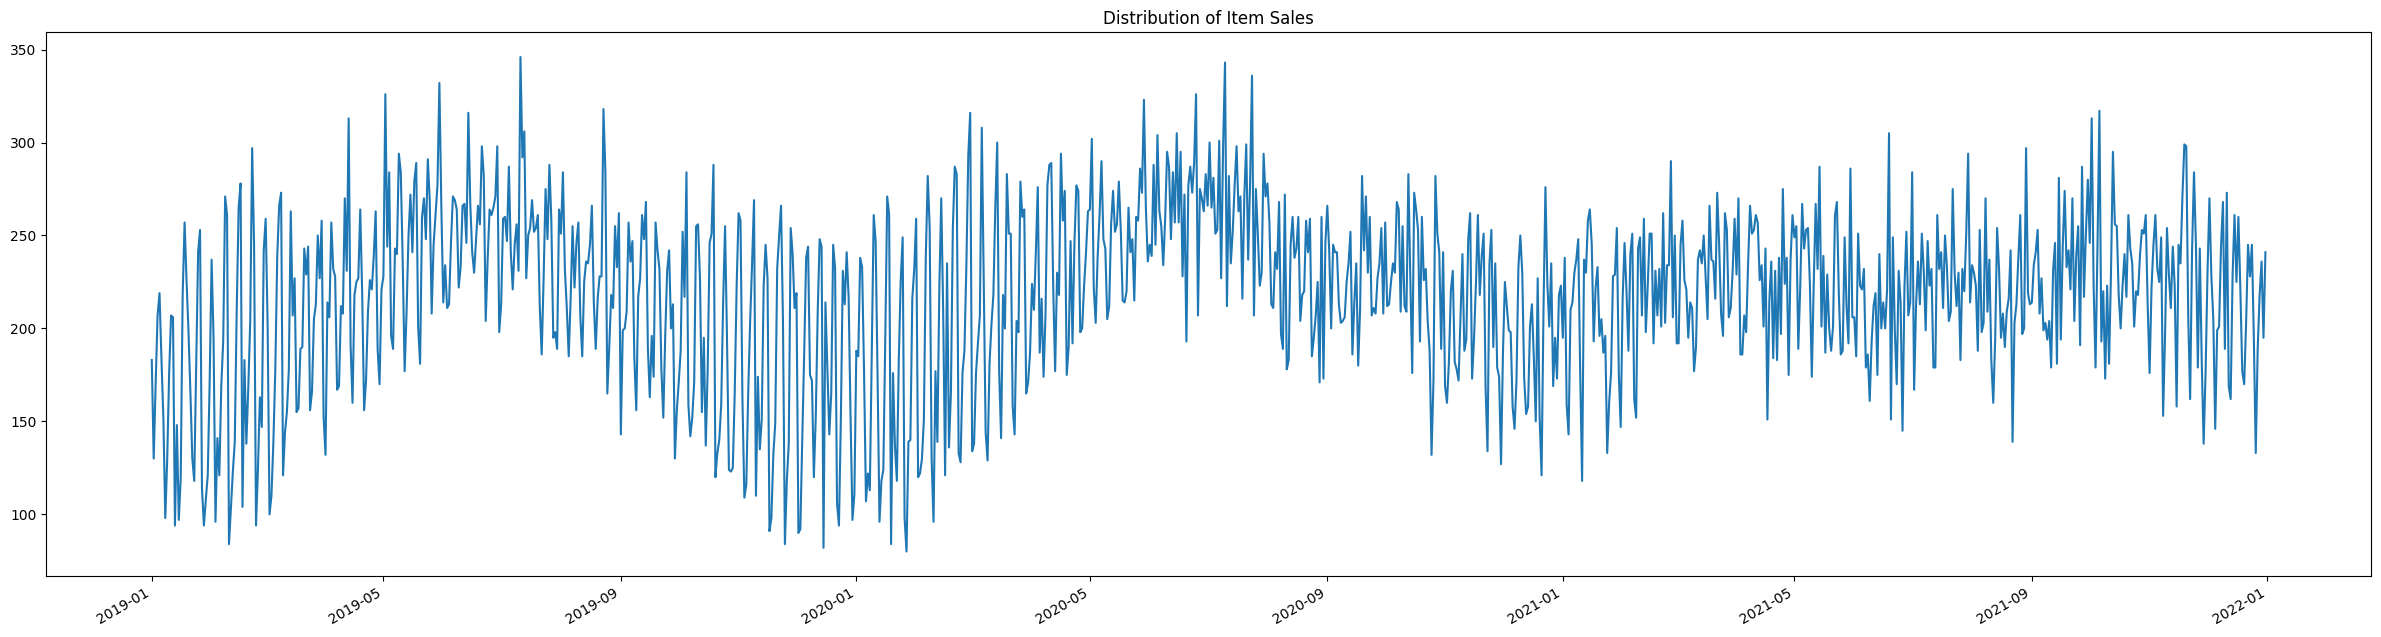

In [13]:
df_item_sales = df_all[["date", "item_count"]].groupby(by=["date"]).sum().reset_index()
fig, ax = plt.subplots(figsize=(30, 8))
ax.plot(df_item_sales["date"], df_item_sales["item_count"])
ax.xaxis_date()
fig.autofmt_xdate()
ax.set_title("Distribution of Item Sales")
plt.show()

In [14]:
df_item_sales

,date,item_count
0,2019-01-01,183.0
1,2019-01-02,130.0
2,2019-01-03,170.0
3,2019-01-04,207.0
4,2019-01-05,219.0
...,...,...
1091,2021-12-27,189.0
1092,2021-12-28,218.0
1093,2021-12-29,236.0
1094,2021-12-30,195.0


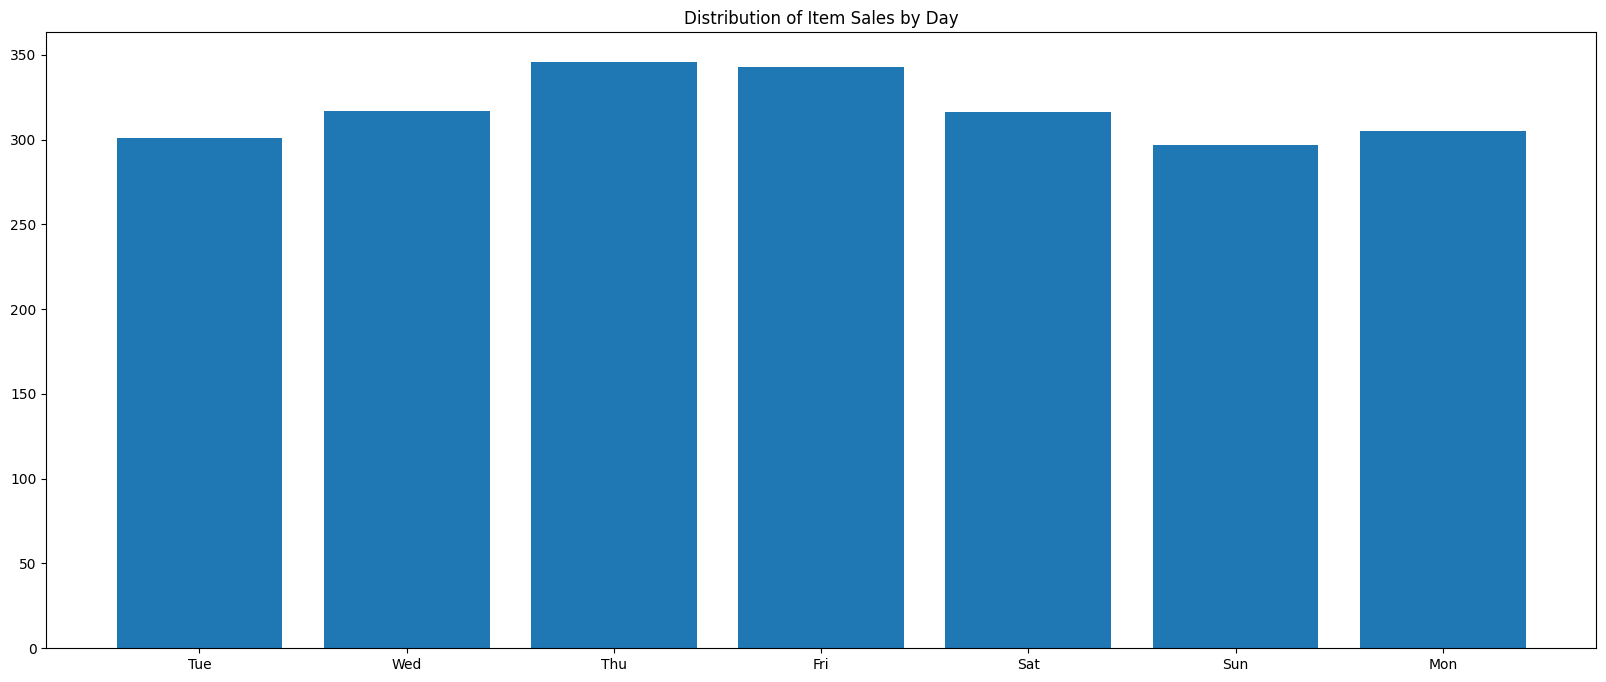

In [15]:
df_item_sales["day"] = df_item_sales["date"].dt.strftime("%a")
fig, ax = plt.subplots(figsize=(20, 8))
ax.bar(df_item_sales["day"], df_item_sales["item_count"])
ax.set_title("Distribution of Item Sales by Day")
plt.show()

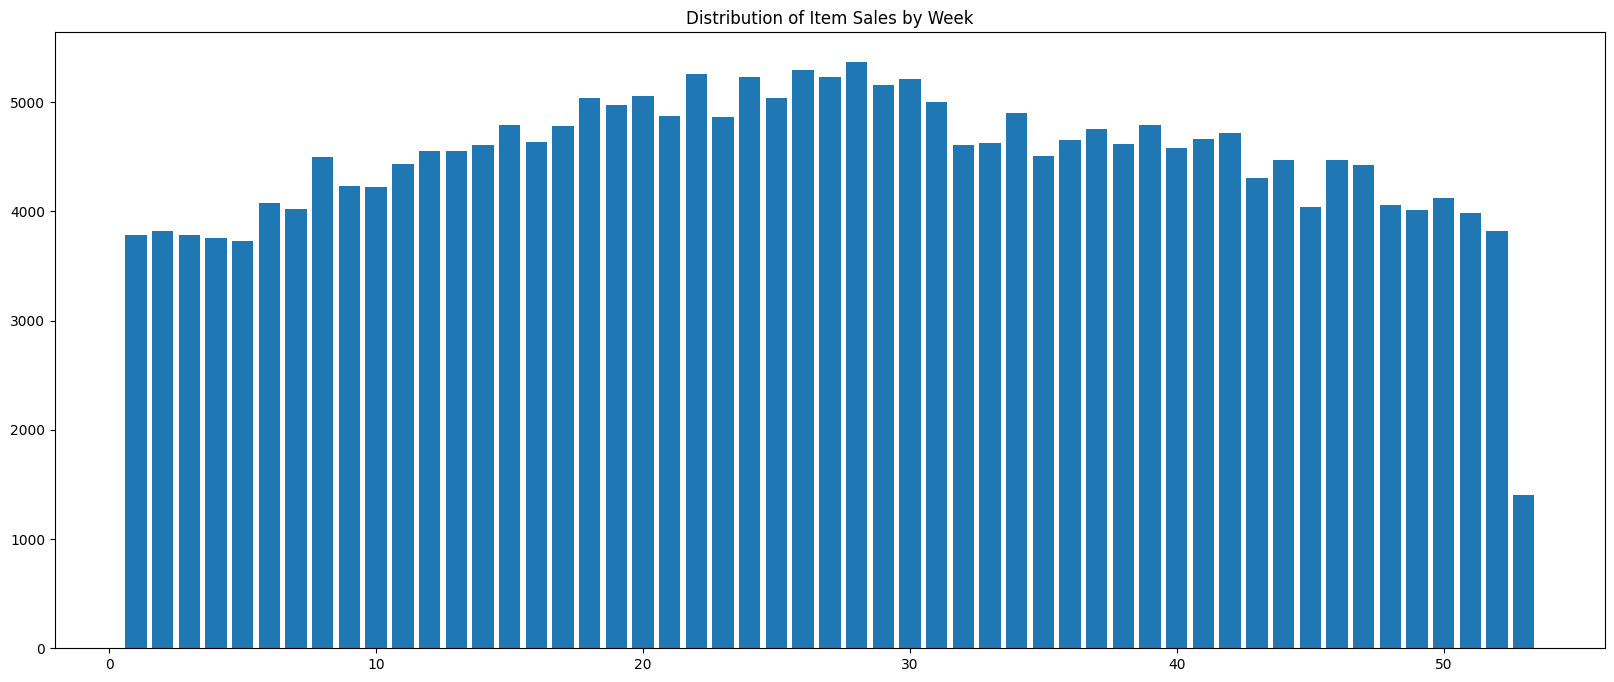

In [16]:
df_item_sales["week"] = df_item_sales["date"].dt.isocalendar().week
df_item_sales_by_week = df_item_sales[["week", "item_count"]].groupby(by=["week"]).sum().reset_index()
fig, ax = plt.subplots(figsize=(20, 8))
ax.bar(df_item_sales_by_week["week"], df_item_sales_by_week["item_count"])
ax.set_title("Distribution of Item Sales by Week")
plt.show()

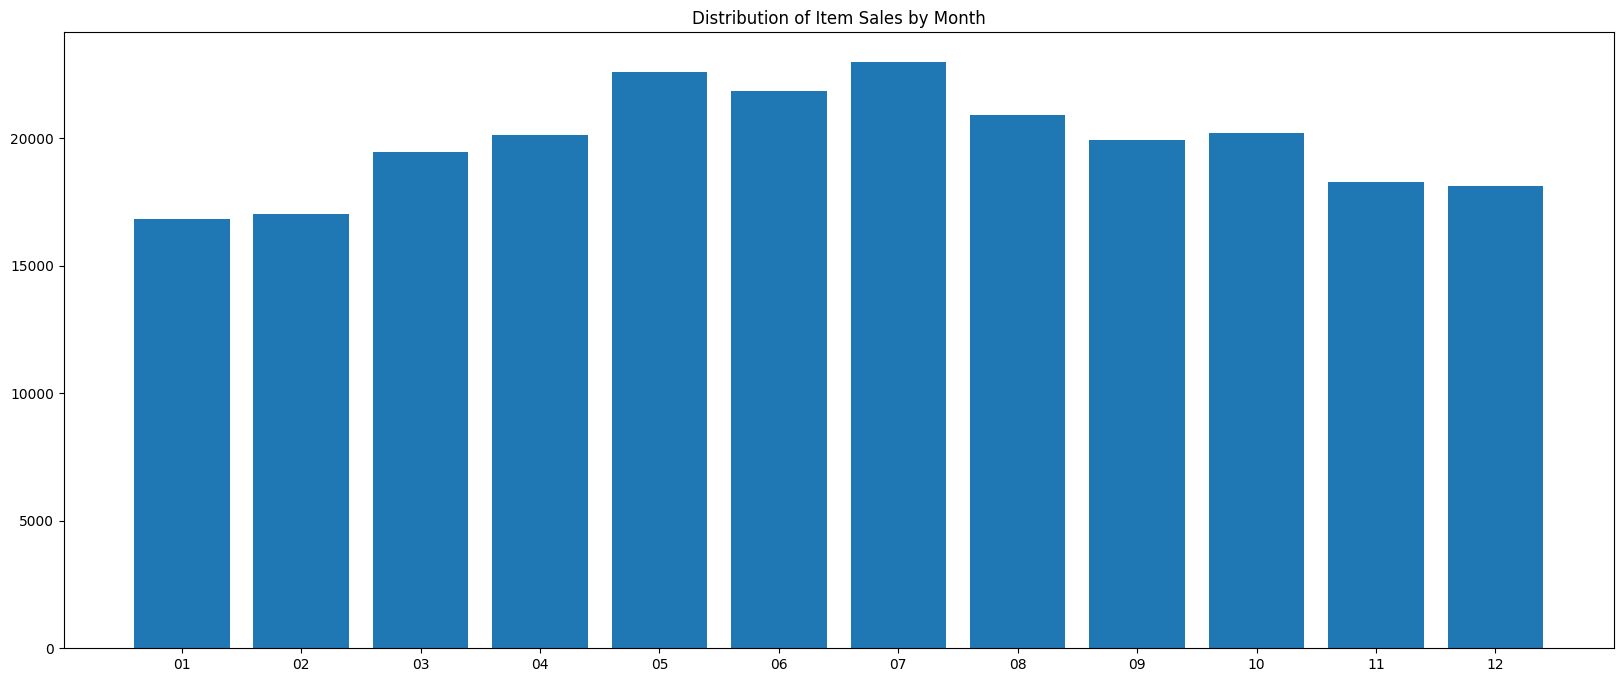

In [17]:
df_item_sales["month"] = df_item_sales["date"].dt.strftime("%m")
df_item_sales_by_month = df_item_sales[["month", "item_count"]].groupby(by=["month"]).sum().reset_index()
fig, ax = plt.subplots(figsize=(20, 8))
ax.bar(df_item_sales_by_month["month"], df_item_sales_by_month["item_count"])
ax.set_title("Distribution of Item Sales by Month")
plt.show()

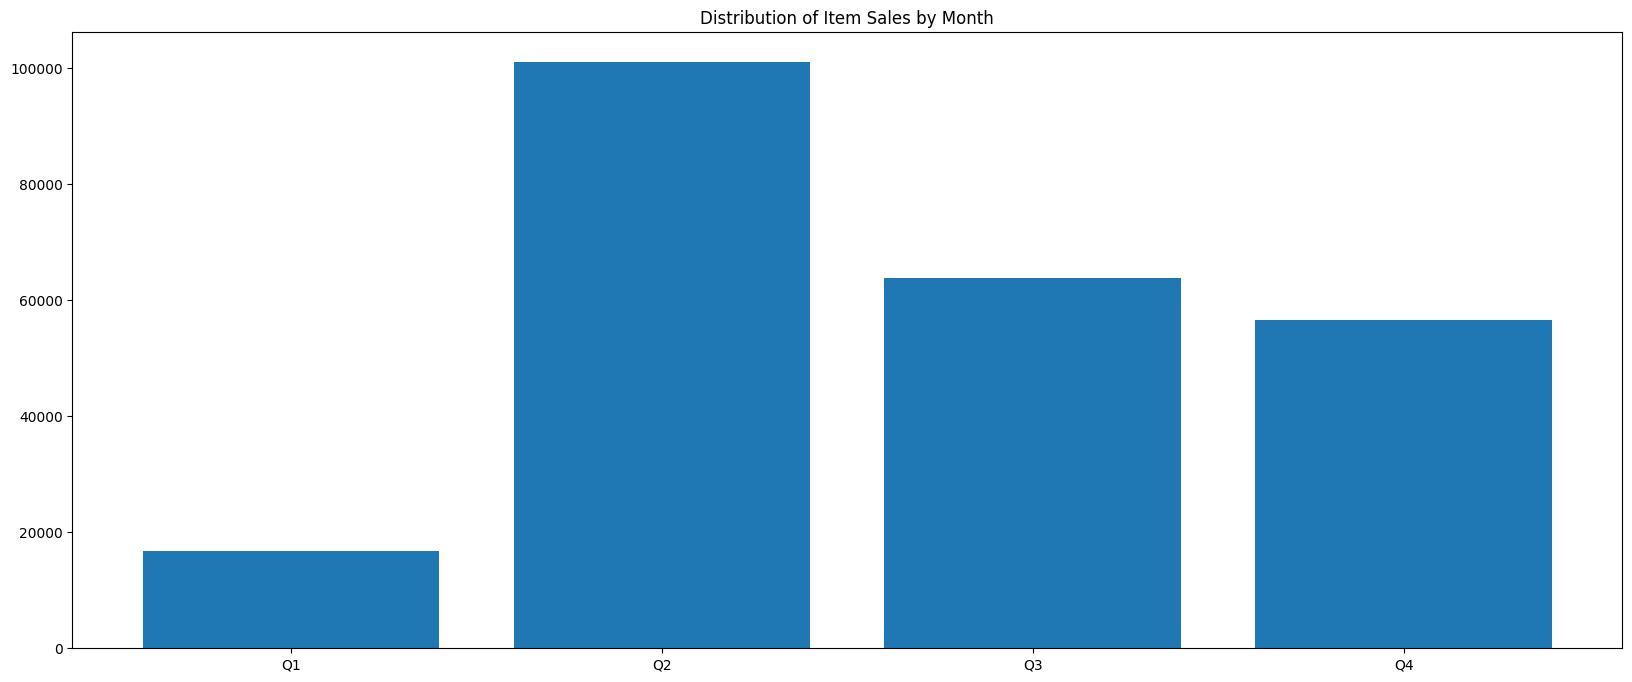

In [18]:
df_item_sales["quarter"] = (df_item_sales["month"].astype(int) / 4 + 1).round().map('Q{:,.0f}'.format)
df_item_sales_by_quarter = df_item_sales[["quarter", "item_count"]].groupby(by=["quarter"]).sum().reset_index()
fig, ax = plt.subplots(figsize=(20, 8)) 
ax.bar(df_item_sales_by_quarter["quarter"], df_item_sales_by_quarter["item_count"])
ax.set_title("Distribution of Item Sales by Month")
plt.show()


In [19]:
df_store_sales = df_all[["store_name", "date", "item_count"]].groupby(by=["store_name", "date"]).sum().reset_index()
df_store_sales["year"] = df_store_sales["date"].dt.strftime("%Y")
df_store_sales["month"] = df_store_sales["date"].dt.strftime("%m")
df_store_sales["day"] = df_store_sales["date"].dt.strftime("%a")
df_store_sales_by_year = df_store_sales[["store_name", "year", "item_count"]].groupby(by=["store_name", "year"]).sum().reset_index()
df_store_sales_by_month = df_store_sales[["store_name", "month", "item_count"]].groupby(by=["store_name", "month"]).sum().reset_index()
df_store_sales_by_day = df_store_sales[["store_name", "day", "item_count"]].groupby(by=["store_name", "day"]).sum().reset_index()

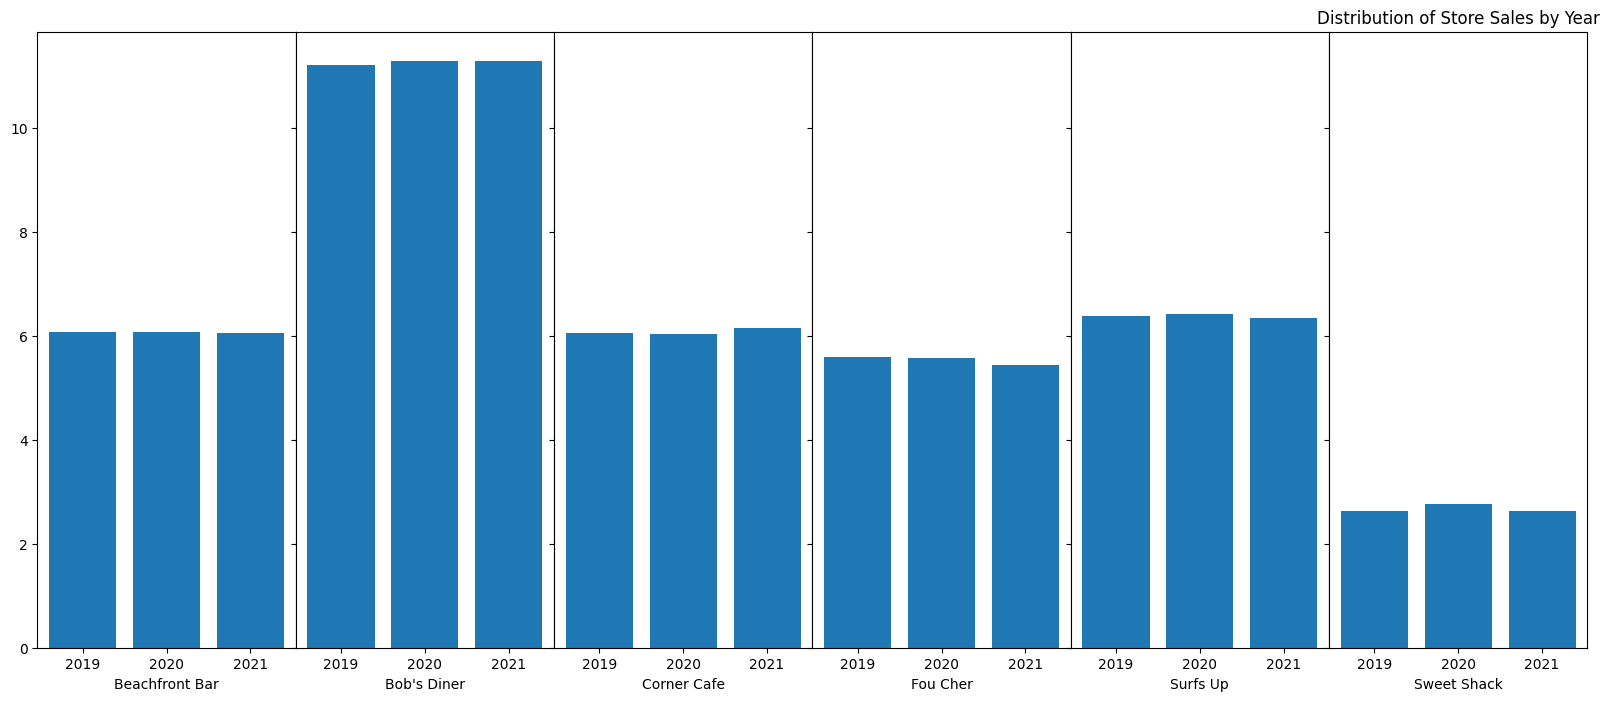

In [20]:
import math
store_names = df_store_sales_by_year["store_name"].unique()
fig, axs = plt.subplots(1, len(store_names), sharey=True, figsize=(20,8))
for ax, store_name in zip(axs, store_names):
 df = df_store_sales_by_year[df_store_sales_by_year["store_name"] == store_name]
 ax.bar(df["year"], df["item_count"].map(math.log))
 ax.set_xlabel(store_name)
ax.set_title("Distribution of Store Sales by Year")
fig.subplots_adjust(wspace=0)
plt.show()


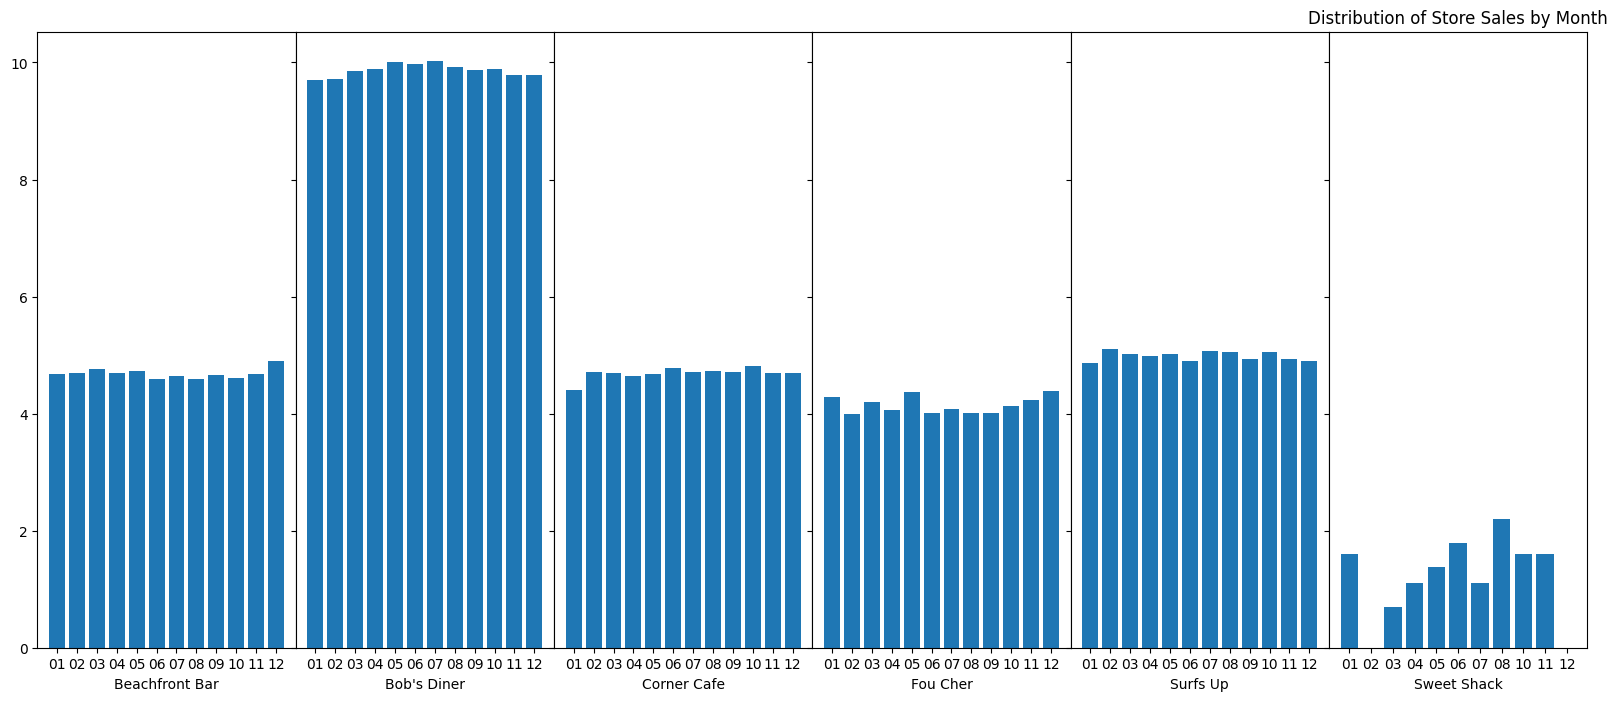

In [21]:
import math
store_names = df_store_sales_by_month["store_name"].unique()
fig, axs = plt.subplots(1, len(store_names), sharey=True, figsize=(20,8))
for ax, store_name in zip(axs, store_names):
 df = df_store_sales_by_month[df_store_sales_by_month["store_name"] == store_name]
 ax.bar(df["month"], df["item_count"].map(math.log))
 ax.set_xlabel(store_name)
ax.set_title("Distribution of Store Sales by Month")
fig.subplots_adjust(wspace=0)
plt.show()

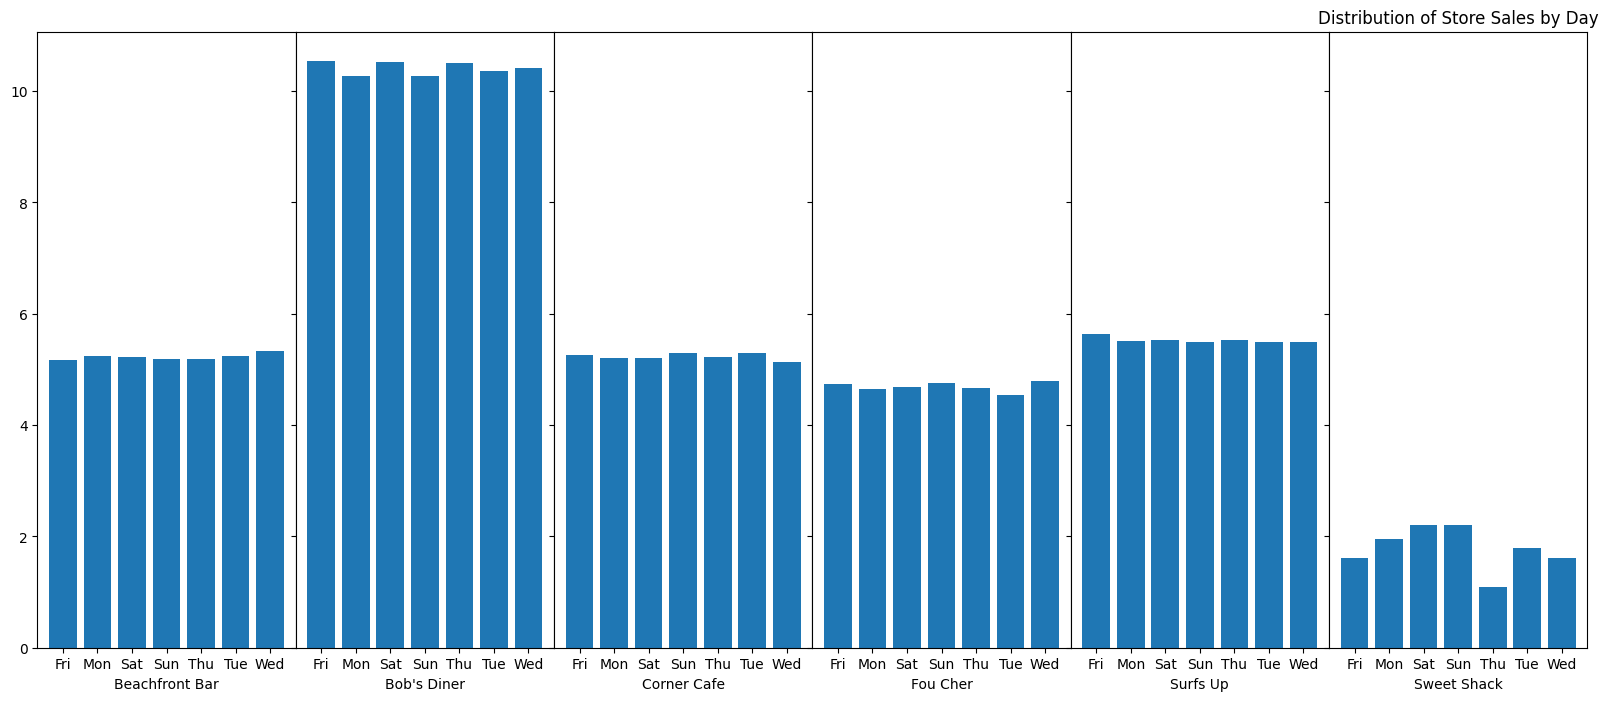

In [22]:
import math
store_names = df_store_sales_by_day["store_name"].unique()
fig, axs = plt.subplots(1, len(store_names), sharey=True, figsize=(20,8))
for ax, store_name in zip(axs, store_names):
 df = df_store_sales_by_day[df_store_sales_by_day["store_name"] == store_name]
 ax.bar(df["day"], df["item_count"].map(math.log))
 ax.set_xlabel(store_name)
ax.set_title("Distribution of Store Sales by Day")
fig.subplots_adjust(wspace=0)
plt.show()

In [23]:
df_pop_sales = df_all[["store_name", "item_name", "item_count"]].groupby(by=["store_name", "item_name"]).sum().reset_index()
df_popitem_sales = df_pop_sales[["item_name", "item_count"]].groupby(by=["item_name"]).sum().sort_values("item_count", ascending=False).reset_index()

C:\Users\Test\AppData\Local\Temp\ipykernel_14708\3452112605.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha="right", va="center_baseline")


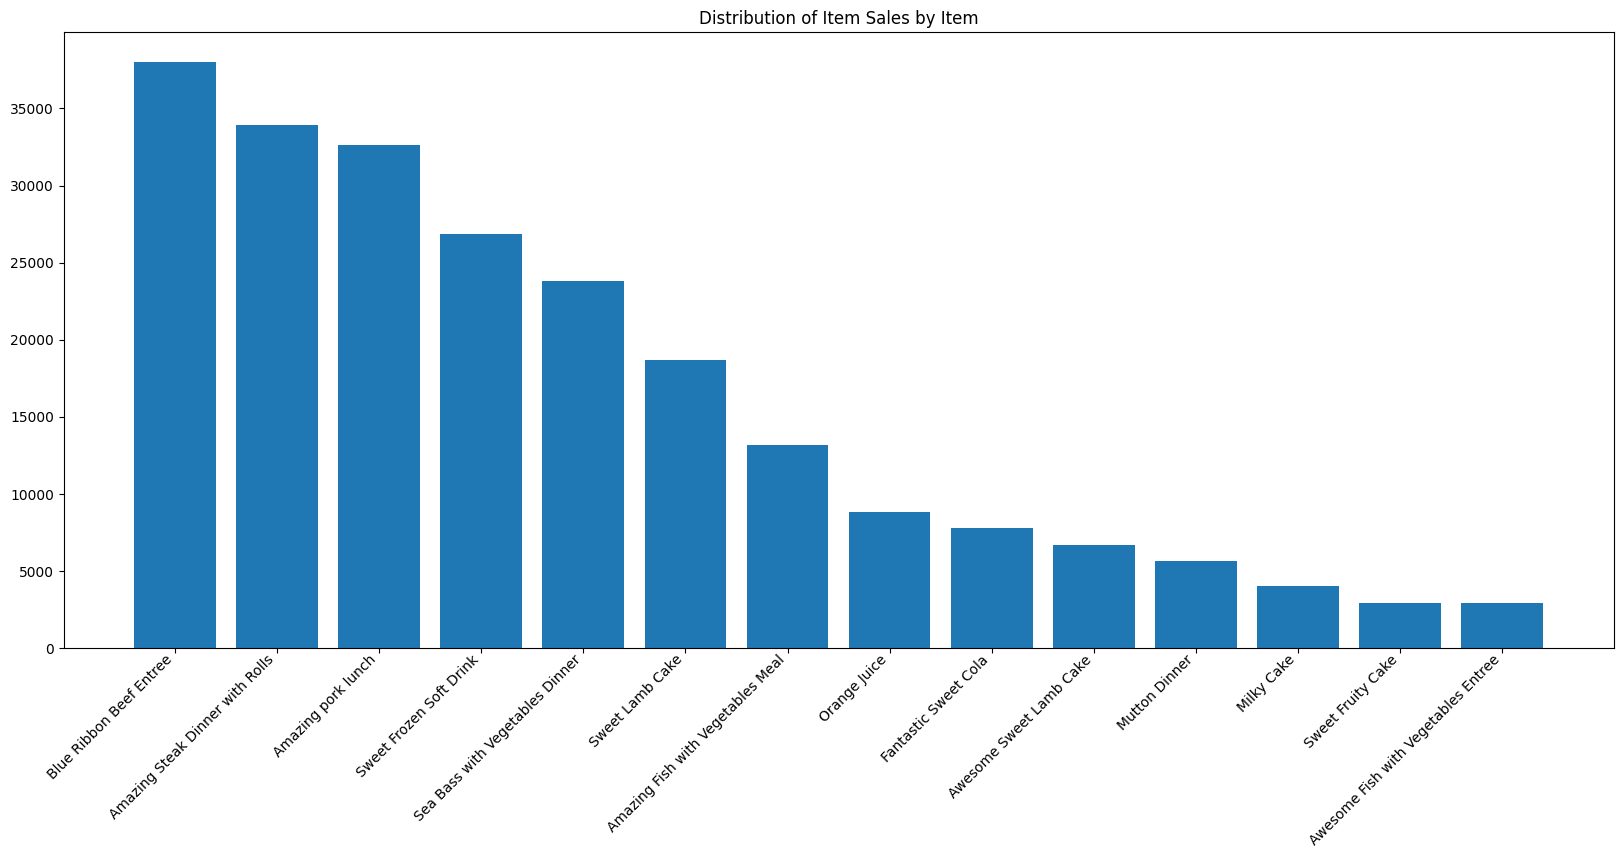

In [24]:
fig, ax = plt.subplots(figsize=(20, 8))
df = df_popitem_sales[df_popitem_sales["item_count"] > 2000]
ax.bar(df["item_name"], df["item_count"])
ax.set_title("Distribution of Item Sales by Item")
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha="right", va="center_baseline")
plt.show()

In [25]:
df_top10_items = df_popitem_sales[df_popitem_sales["item_count"] > 2000].iloc[:10,:]
df_top10_items

,item_name,item_count
0,Blue Ribbon Beef Entree,38034.0
1,Amazing Steak Dinner with Rolls,33940.0
2,Amazing pork lunch,32631.0
3,Sweet Frozen Soft Drink,26860.0
4,Sea Bass with Vegetables Dinner,23839.0
5,Sweet Lamb Cake,18696.0
6,Amazing Fish with Vegetables Meal,13190.0
7,Orange Juice,8835.0
8,Fantastic Sweet Cola,7791.0
9,Awesome Sweet Lamb Cake,6674.0


In [26]:
df_store_items = df_all[["store_name", "item_name"]]
df_store_items[df_store_items["item_name"].isin(df_top10_items["item_name"])]["store_name"].unique()

array(["Bob's Diner"], dtype=object)

In [27]:
df_all[["store_name", "item_count"]].groupby(["store_name"]).sum().sort_values(by="item_count", ascending=False).reset_index()

,store_name,item_count
0,Bob's Diner,233248.0
1,Surfs Up,1762.0
2,Corner Cafe,1310.0
3,Beachfront Bar,1305.0
4,Fou Cher,766.0
5,Sweet Shack,44.0


In [28]:
df_all["sale_amount"] = df_all["item_count"] * df_all["price"]
df = df_all[["store_name", "date"]].groupby(["store_name", "date"]).count().reset_index()
df_days = df.groupby(["store_name"]).count().rename({"date": "days"}, axis=1).reset_index()
df_sale_amount = df_all[["store_name", "sale_amount"]].groupby(["store_name"]).sum().reset_index()

In [29]:
df_sales_days = pd.merge(df_sale_amount, df_days, on=['store_name'])
df_sales_days["sales_per_day"] = df_sales_days["sale_amount"] / df_sales_days["days"]
df_sales_days.sort_values(by="sales_per_day", ascending=False)

,store_name,sale_amount,days,sales_per_day
1,Bob's Diner,4045933.15,1096,3691.544845
2,Corner Cafe,16551.43,783,21.138480
3,Fou Cher,10999.65,590,18.643475
4,Surfs Up,14798.69,893,16.571881
5,Sweet Shack,226.39,44,5.145227
0,Beachfront Bar,3796.20,806,4.709926


In [30]:
df_costly_items = df_all[["store_name", "item_name", "price", "kcal"]].groupby(["store_name", "item_name"]).max().sort_values(by=["store_name","price"], ascending=False)
df_costly_items.loc

In [31]:
for store_name in df_costly_items.index.get_level_values(0).unique():
 print(df_costly_items.loc[[store_name]].iloc[0])

price      6.89
kcal     612.00
Name: (Sweet Shack, Blue Ribbon Milky Cake), dtype: float64
price     26.21
kcal     607.00
Name: (Surfs Up, Steak Meal), dtype: float64
price     28.65
kcal     744.00
Name: (Fou Cher, Original Fruity Cod with Bread and Vegetables Entree), dtype: float64
price     26.37
kcal     653.00
Name: (Corner Cafe, Pike Lunch), dtype: float64
price     29.22
kcal     931.00
Name: (Bob's Diner, Sweet Fruity Cake), dtype: float64
price      5.7
kcal     538.0
Name: (Beachfront Bar, Sweet Vegi Soft Drink), dtype: float64


# Machine Learning

## Build and compare linear regression, random forest, and XGBoost models for predictions

<Axes: ylabel='price'>

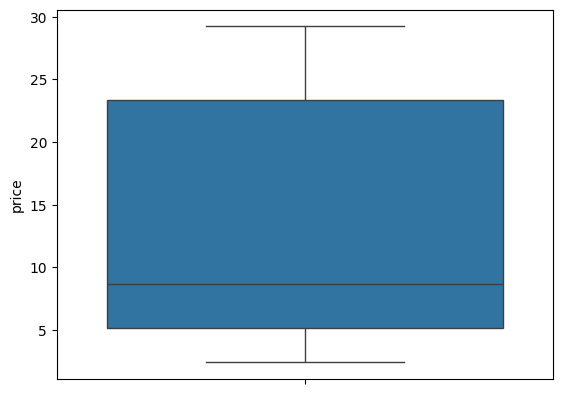

In [32]:
import seaborn as sns
sns.boxplot(df_all['price'])

In [33]:
df_all["day"] = df_all["date"].dt.strftime("%w").astype(int)
df_all["week"] = df_all["date"].dt.isocalendar().week
df_all["month"] = df_all["date"].dt.strftime("%m").astype(int)
df_all["year"] = df_all["date"].dt.strftime("%Y").astype(int)
df_all["quarter"] = (df_all["month"].astype(int) / 4 + 1).round().astype(int)

In [34]:
train = df_all[df_all["date"] <= '2021-06-30']
test = df_all[df_all["date"] > '2021-06-30']
X_train = train.drop('item_count', axis=1)[["date_int", "item_id", "price", "kcal", "store_id"]]
X_test = test.drop('item_count', axis=1)[["date_int", "item_id", "price", "kcal", "store_id"]]
y_train = train["item_count"]
y_test = test["item_count"]


# Linear Regression

In [38]:
import statsmodels.formula.api as sm
model = sm.ols(formula="item_count ~ date_int + item_id + price + kcal + store_id", data=train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             item_count   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     706.7
Date:                Tue, 23 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:10:17   Log-Likelihood:                -65144.
No. Observations:               16028   AIC:                         1.303e+05
Df Residuals:                   16022   BIC:                         1.303e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -36.6836    303.454     -0.121      0.9

In [40]:
def calculate_residuals(model, features, label):
 predictions = model.predict(features)
 df_results = pd.DataFrame({'Actual' : label, 'Predicted' : predictions})
 df_results['Residuals'] = abs(df_results['Actual']) - abs(df_results['Predicted'])
 return df_results
def linear_assumptions(model, features, label):
 df_results = calculate_residuals(model, features, label)
 sns.lmplot(x='Actual', y='Predicted', data=df_results, fit_reg=False, height=7)
 line_coords = np.arange(df_results.min().min(), df_results.max().max())
 plt.plot(line_coords, line_coords, color='darkorange', linestyle='--')
 plt.title('Actual vs. Predicted')
 plt.show()


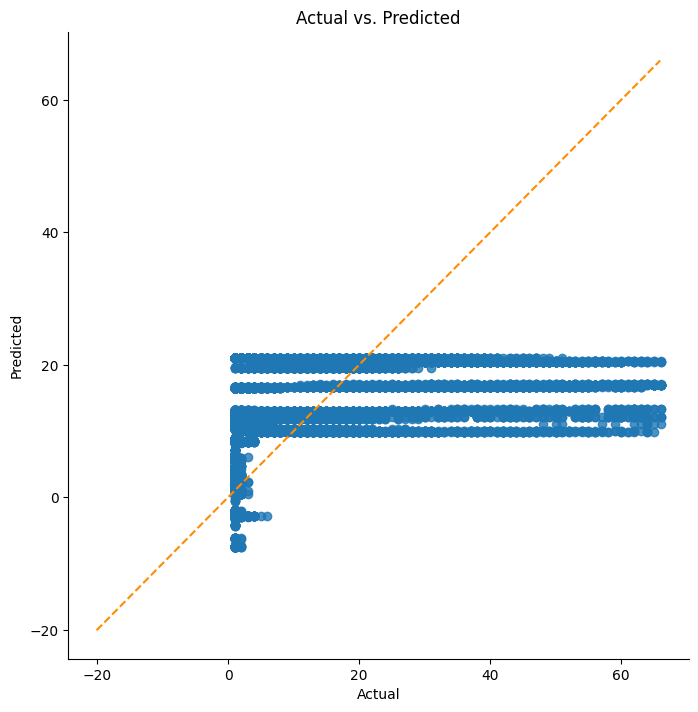

In [41]:
data = X_train
target = y_train
linear_assumptions(model, data, target)

In [42]:
corr = data.corr()
corr.style.background_gradient(cmap='coolwarm')

,date_int,item_id,price,kcal,store_id
date_int,1.000000,0.005188,-0.039520,-0.010691,-0.006012
item_id,0.005188,1.000000,-0.209976,-0.128256,0.356341
price,-0.039520,-0.209976,1.000000,0.244986,-0.162693
kcal,-0.010691,-0.128256,0.244986,1.000000,-0.287748
store_id,-0.006012,0.356341,-0.162693,-0.287748,1.000000


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np
x = data.astype(float) # Convert the array to float type
vif_data = pd.DataFrame()
vif_data['Features'] = x.columns
vif_data['vif'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
print(vif_data)


   Features        vif
0  date_int  14.978566
1   item_id   4.003885
2     price   3.479351
3      kcal   8.923229
4  store_id   2.729025


In [44]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [45]:
import statsmodels.api as sm
X_train = pd.DataFrame(X_train)
y_train = pd.DataFrame(y_train)
X_test = pd.DataFrame(X_test)
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')
X_train = np.asarray(X_train)
y_train = np.asarray(y_train)
X_test = np.asarray(X_test)
print(X_train.dtype)
print(y_train.dtype)
print(np.isnan(X_train).sum())
print(np.isnan(y_train).sum())
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

float64
float64
0
0
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.111
Model:                            OLS   Adj. R-squared (uncentered):              0.111
Method:                 Least Squares   F-statistic:                              400.9
Date:                Tue, 23 Dec 2025   Prob (F-statistic):                        0.00
Time:                        12:13:26   Log-Likelihood:                         -69686.
No. Observations:               16028   AIC:                                  1.394e+05
Df Residuals:                   16023   BIC:                                  1.394e+05
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

In [46]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)
y_pred_train = reg.predict(X_train)
y_pred_test = reg.predict(X_test)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("R Square: {}".format(r2_score(y_train, y_pred_train)))
print("MAE: {}".format(mean_absolute_error(y_train, y_pred_train)))
print("MSE: {}".format(mean_squared_error(y_train, y_pred_train)))

R Square: 0.18068645443845277
MAE: 10.543814666267837
MSE: 198.51305881591463


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("R Square: {}".format(r2_score(y_test, y_pred_test)))
print("MAE: {}".format(mean_absolute_error(y_test, y_pred_test)))
print("MSE: {}".format(mean_squared_error(y_test, y_pred_test)))

R Square: 0.14602143977302606
MAE: 11.262596645806331
MSE: 224.36872195807788


# Random Forest

In [49]:
from sklearn.ensemble import RandomForestRegressor
yy_train = y_train.ravel()
regressor = RandomForestRegressor(n_estimators=20, random_state=0)
regressor.fit(X_train, yy_train)
y_pred_train = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("R Square: {}".format(r2_score(yy_train, y_pred_train)))
print("MAE: {}".format(mean_absolute_error(yy_train, y_pred_train)))
print("MSE: {}".format(mean_squared_error(yy_train, y_pred_train)))

R Square: 0.9792855718803697
MAE: 1.2112802595457948
MSE: 5.018938732218618


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("R Square: {}".format(r2_score(y_test, y_pred_test)))
print("MAE: {}".format(mean_absolute_error(y_test, y_pred_test)))
print("MSE: {}".format(mean_squared_error(y_test, y_pred_test)))

R Square: 0.6233883111922519
MAE: 5.149200581395349
MSE: 98.94848328488371


# XGBoost

# Forecast

### Use the best-performing models to make a forecast for the next year

### Since the Random Forest has a better R Score than Regression model, we will use the model from Random Forest to perform the forecasting

In [54]:
forecast_year = 2024
all_items = df_items.drop('name', axis=1).rename({"id": "item_id"}, axis=1)
daterange = pd.date_range(f"{forecast_year}-01-01", f"{forecast_year}-12-31")
forecast_year_date_ints = daterange.map(lambda dt: int(dt.strftime('%Y%m%d')))
X_forecast = pd.DataFrame()
n_items = all_items.shape[0]
for dt in forecast_year_date_ints:
 dts = pd.DataFrame({"date_int": np.full(n_items, dt)})
 items = pd.concat((dts, all_items), axis=1)
 X_forecast = pd.concat((X_forecast, items), axis=0)


In [55]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_forecast_scaled = sc.fit_transform(X_forecast)
y_forecast = regressor.predict(np.asarray(X_forecast_scaled))


In [56]:
X_forecast = X_forecast.merge(df_restaurants, right_on="id", left_on="store_id", left_index=False, right_index=False)
X_forecast = X_forecast.rename({"name":"store_name"}, axis=1).reset_index()

In [57]:
X_forecast["item_count"] = y_forecast
X_forecast["date"] = X_forecast["date_int"].astype("str")
X_forecast["month"] = X_forecast["date"].str[4:6]
X_forecast

,index,date_int,item_id,store_id,kcal,cost,id,store_name,name_F,item_count,date,month
0,0,20240101,1,4,554,6.71,4,Fou Cher,3,12.15,20240101,01
1,1,20240101,2,4,772,15.09,4,Fou Cher,3,1.00,20240101,01
2,2,20240101,3,1,931,29.22,1,Bob's Diner,0,1.00,20240101,01
3,3,20240101,4,1,763,26.42,1,Bob's Diner,0,1.00,20240101,01
4,4,20240101,5,5,583,6.07,5,Corner Cafe,4,12.15,20240101,01
...,...,...,...,...,...,...,...,...,...,...,...,...
36595,36595,20241231,96,5,708,21.93,5,Corner Cafe,4,1.00,20241231,12
36596,36596,20241231,97,4,744,28.65,4,Fou Cher,3,1.00,20241231,12
36597,36597,20241231,98,2,579,5.00,2,Beachfront Bar,1,16.85,20241231,12
36598,36598,20241231,99,4,423,5.32,4,Fou Cher,3,57.20,20241231,12


In [58]:
df_forecast_store_sales_by_month = X_forecast[["store_name", "month", "item_count"]].groupby(by=["store_name", "month"]).sum().reset_index()

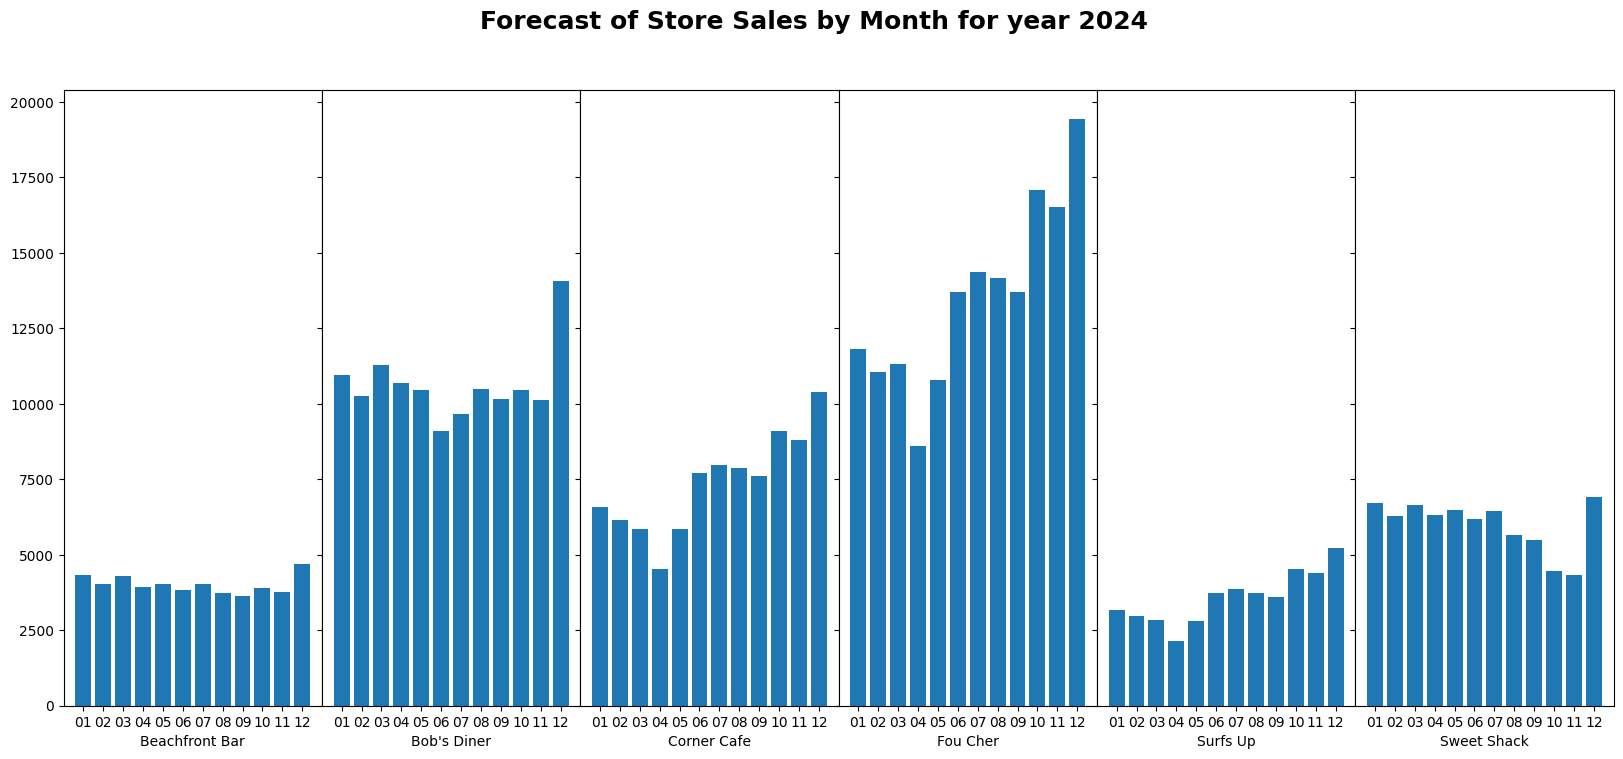

In [59]:
store_names = df_forecast_store_sales_by_month["store_name"].unique()
fig, axs = plt.subplots(1, len(store_names), sharey=True, figsize=(20,8))
for ax, store_name in zip(axs, store_names):
 df = df_forecast_store_sales_by_month[df_forecast_store_sales_by_month["store_name"] == store_name]
 ax.bar(df["month"], df["item_count"])
 ax.set_xlabel(store_name)
fig.subplots_adjust(wspace=0)
plt.suptitle(f"Forecast of Store Sales by Month for year {forecast_year}", fontsize=18, fontweight="bold")
plt.show()


# Deep Learning

#### Forecasting using deep learning algorithms

In [60]:
df_sales = df_all[["date", "sale_amount"]].groupby("date").sum()
train = df_sales[df_sales.index < '2021-07-01']
test = df_sales[df_sales.index >= '2021-07-01']

In [61]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train)
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

##### Define the train and test series

In [62]:
import tensorflow as tf
n_features = 1
length = 12
generator = tf.keras.preprocessing.sequence.TimeseriesGenerator(scaled_train, scaled_train, length=12, batch_size=1)

In [63]:
import tensorflow as tf
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer((length, n_features)))
model.add(tf.keras.layers.LSTM(24, return_sequences=True))
model.add(tf.keras.layers.Dropout(.5))
model.add(tf.keras.layers.LSTM(48, return_sequences=True))
model.add(tf.keras.layers.Dropout(.5))
model.add(tf.keras.layers.Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 12, 24)              │           2,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 24)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 12, 48)              │          14,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 48)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 12, 1)               │              49 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,561 (64.69 KB)

 Trainable params: 16,561 (64.69 KB)

 Non-trainable params: 0 (0.00 B)

#### Generate synthetic data for the last 12 months

In [64]:
validation_generator = tf.keras.preprocessing.sequence.TimeseriesGenerator(scaled_test, scaled_test, length=12, batch_size=1)

#### Build and train an LSTM model

In [65]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=.0001, patience=3, mode='auto')
model.fit(generator, epochs=20, validation_data = validation_generator, callbacks=[early_stop])

Epoch 1/20


C:\Users\Test\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


900/900 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 0.0537 - val_loss: 0.0314
Epoch 2/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.0409 - val_loss: 0.0266
Epoch 3/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0386 - val_loss: 0.0265
Epoch 4/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0374 - val_loss: 0.0254
Epoch 5/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0368 - val_loss: 0.0256
Epoch 6/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0358 - val_loss: 0.0263
Epoch 7/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0355 - val_loss: 0.0257


##### Use the model to make predictions for the test data

In [66]:
test_preds = []
curr_batch = scaled_train[-length:]
for i in range(len(test)):
 curr_pred = model.predict(curr_batch)[0]
 test_preds.append(curr_pred[0])
 curr_batch = np.vstack((curr_batch[1:], curr_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━

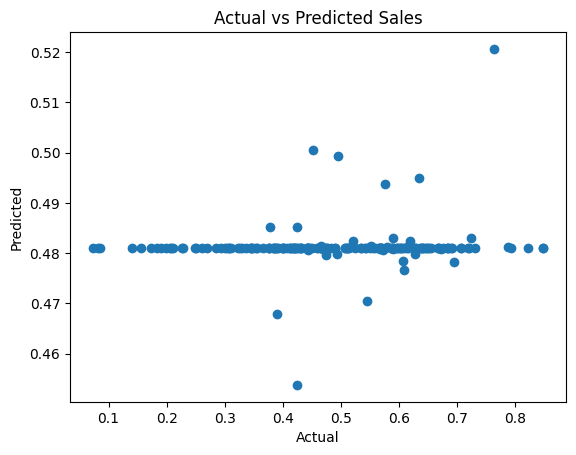

In [67]:
plt.scatter(scaled_test, test_preds)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Sales')
plt.show()

#### Calculate the mean absolute percentage error (MAPE) and comment on the model's performance

In [68]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
print("R Square: {}".format(r2_score(scaled_test, test_preds)))
print("MAPE: {}".format(mean_absolute_percentage_error(scaled_test, test_preds)))
print("MSE: {}".format(mean_squared_error(scaled_test, test_preds)))

R Square: 0.004473016039736155
MAPE: 0.3814294744918304
MSE: 0.02417796939139113


## Forecast
#### Develop another model using the entire series for training, and use it to forecast for the next three months

In [69]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(df_sales)
scaled_train = scaler.transform(df_sales)

In [70]:
import tensorflow as tf
n_features = 1
length = 12
generator = tf.keras.preprocessing.sequence.TimeseriesGenerator(scaled_train, scaled_train, length=12, batch_size=1)

In [72]:
import tensorflow as tf
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer((length, n_features)))
model.add(tf.keras.layers.LSTM(24, return_sequences=True))
model.add(tf.keras.layers.Dropout(.5))
model.add(tf.keras.layers.LSTM(48, return_sequences=True))
model.add(tf.keras.layers.Dropout(.5))
model.add(tf.keras.layers.Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 12, 24)              │           2,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 12, 24)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 12, 48)              │          14,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 12, 48)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12, 1)               │              49 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,561 (64.69 KB)

 Trainable params: 16,561 (64.69 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=.0001, patience=3, mode='auto')
model.fit(generator, epochs=20, callbacks=[early_stop])

Epoch 1/20


C:\Users\Test\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1084/1084 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0495
Epoch 2/20
  12/1084 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0261

C:\Users\Test\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


1084/1084 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0381
Epoch 3/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0361
Epoch 4/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0351
Epoch 5/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0345
Epoch 6/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0339
Epoch 7/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0333
Epoch 8/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0324
Epoch 9/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0314
Epoch 10/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0298
Epoch 11/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.0290
Epoch 12/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0276
Epoch 13/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0270
Epoch 14/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 2184s 2s/step - loss: 0.0262
Epoch 16/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 0.0262
Epoch 17/20

In [74]:
daterange = pd.date_range(f"2022-01-01", f"2022-03-31")
df_forecast = pd.DataFrame({"date": daterange, "sale_amount": [0.0] * daterange.size})
df_forecast.set_index(['date'], inplace=True)
scaled_dts = scaler.transform(df_forecast)

In [75]:
forecast_preds = []
curr_batch = scaled_dts[-length:]
for i in range(len(scaled_dts)):
 curr_pred = model.predict(curr_batch)[0]
 forecast_preds.append(curr_pred[0])
 curr_batch = np.vstack((curr_batch[1:], curr_pred))
forecast_preds = scaler.inverse_transform(forecast_preds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━

In [77]:
df_forecast["sale_amount"] = forecast_preds.ravel()
df_forecast["month"] = df_forecast.index.month
df_forecast_by_month = df_forecast.groupby("month").sum()

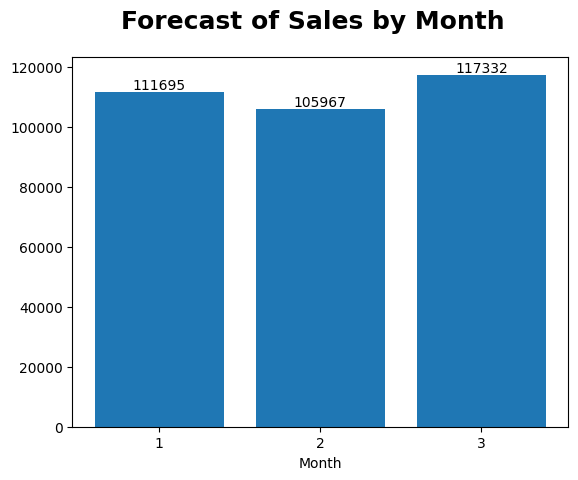

In [79]:
bar = plt.bar(df_forecast_by_month.index, df_forecast_by_month["sale_amount"])
plt.bar_label(bar, label_type='edge')
plt.xticks(df_forecast_by_month.index)
plt.xlabel("Month")
plt.suptitle(f"Forecast of Sales by Month", fontsize=18, fontweight="bold")
plt.show()